In [1]:
from google.colab import files
uploaded = files.upload()

Saving iris (2).csv to iris (2).csv


In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load the 'iris (2).csv' dataset into a DataFrame called df
df = pd.read_csv('/content/iris (2).csv')

# Create a feature DataFrame X by dropping the 'species' column from df
X = df.drop('species', axis=1)

# Create a target Series y containing only the 'species' column from df
y = df['species']

# Instantiate LabelEncoder and fit it to the y Series, then transform y
le = LabelEncoder()
y = le.fit_transform(y)

# Split the X and y data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and preprocessed successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data loaded and preprocessed successfully.
X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier with n_estimators=10 and random_state=42
rf_classifier = RandomForestClassifier(n_estimators=10, random_state=42)

# Train the classifier using the training data
rf_classifier.fit(X_train, y_train)

# Calculate the prediction score (accuracy) on the test data
accuracy = rf_classifier.score(X_test, y_test)

# Print the accuracy
print(f"Accuracy for n_estimators=10: {accuracy:.4f}")

Accuracy for n_estimators=10: 1.0000


In [10]:
import numpy as np

# Initialize an empty list to store scores
scores = []

# Iterate through n_estimators from 1 to 200
for n_est in range(1, 201):
    # Instantiate a RandomForestClassifier with the current n_estimators
    rf_tuned_classifier = RandomForestClassifier(n_estimators=n_est, random_state=42)

    # Train the classifier
    rf_tuned_classifier.fit(X_train, y_train)

    # Calculate the prediction score (accuracy) on the test data
    accuracy = rf_tuned_classifier.score(X_test, y_test)

    # Append the score to the list
    scores.append(accuracy)

print(f"Completed training and scoring for {len(scores)} different n_estimators values.")
print(f"Example scores (first 5): {scores[:5]}")

Completed training and scoring for 200 different n_estimators values.
Example scores (first 5): [1.0, 0.9666666666666667, 1.0, 0.9666666666666667, 0.9666666666666667]


In [11]:
max_score = np.max(scores)
optimal_n_estimators = np.argmax(scores) + 1 # +1 because n_estimators started from 1

print(f"Best prediction score: {max_score:.4f}")
print(f"Optimal n_estimators: {optimal_n_estimators}")

Best prediction score: 1.0000
Optimal n_estimators: 1


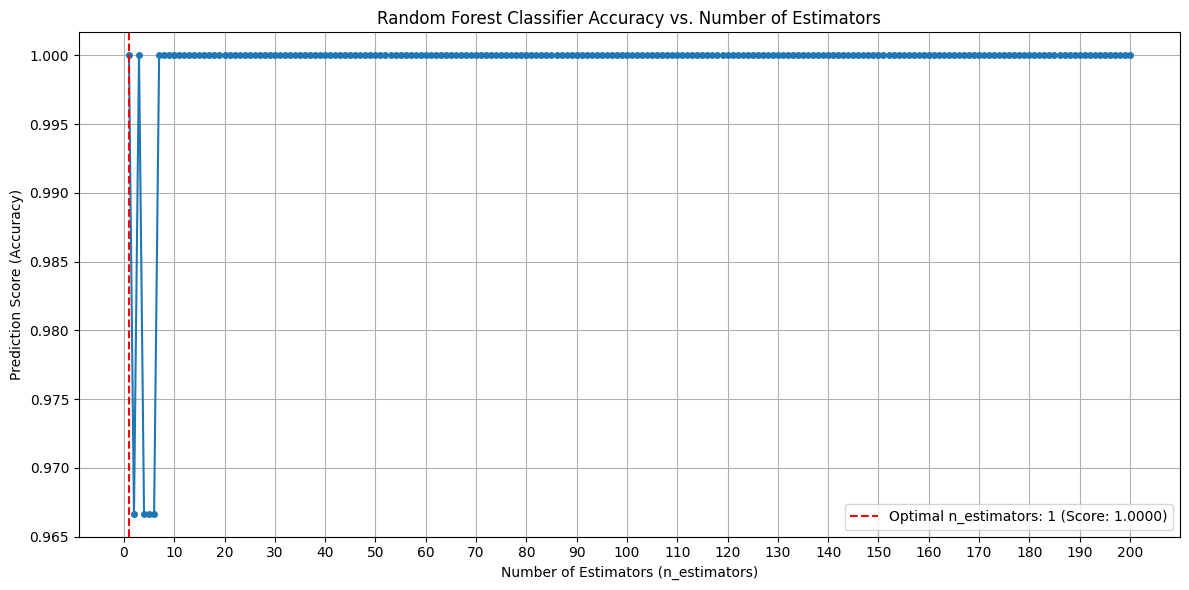

Plot generated successfully.


In [12]:
import matplotlib.pyplot as plt

# Create a range of n_estimators values for the x-axis
n_estimators_range = range(1, 201)

# Plot the scores
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, scores, marker='o', linestyle='-', markersize=4)
plt.title('Random Forest Classifier Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Prediction Score (Accuracy)')
plt.xticks(np.arange(0, 201, 10))
plt.grid(True)

# Highlight the optimal n_estimators
plt.axvline(x=optimal_n_estimators, color='r', linestyle='--', label=f'Optimal n_estimators: {optimal_n_estimators} (Score: {max_score:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

print("Plot generated successfully.")